In [1]:
import os
import json
import random
import string
from typing import Annotated, TypedDict, List, Sequence, Optional, Dict
from operator import add
from langchain_groq import ChatGroq 
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.types import Command
from langchain_core.messages import BaseMessage,HumanMessage,SystemMessage,AIMessage,ToolMessage
from langgraph.graph.message import add_messages
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, InjectedState, tools_condition
from dotenv import load_dotenv
from rich import print as rprint

In [2]:
load_dotenv()
api_key = os.getenv("GROQ_API_KEY")

In [3]:
llm = ChatGroq(model="llama-3.1-8b-instant")

In [4]:
def merge_dicts(left:dict, right:dict)->dict:

    if not right: return left
    if not left: return right

    def is_empty(v):
        return v is None or str(v).strip().lower() in ("none","null","")

    return {**left, **{k:v for k,v in right.items() if not is_empty(v)}}

class SupervisorState(MessagesState):
    """
        State for multi-agent system
    """   
    user_input: str
    user_intent: str

    actions_taken: str
    observations: Annotated[list, add]
    response: Annotated[list, add]
    
    complaint_data: Annotated[dict, merge_dicts]
    missing_info: list
    next: str
    customer_profile: Dict
    

In [5]:
# Supervisor Node
def supervisor_node(state:SupervisorState)->SupervisorState:

 
    history = state.get("observations", [])
    user_input = state.get("user_input")
    current_intent = state.get("user_intent", "unknown")

 
    system_prompt = f"""
    You are an intent classifier.
    
    PREVIOUS CONTEXT: {history[-3:]} # Look at last 3 interactions for speed
    CURRENT INTENT: {current_intent}

    Classify the new user message: "{user_input}"
    
    INTENTS: [inquiry, complaint, churn, unknown]

    GUIDELINES:
    - If the user is answering a question you just asked, KEEP the current intent.
    - Only change the intent if the user clearly switches topics.
    - Return ONLY the label.

    Examples:
    "hello" (with no history) → unknown
    "I don't know" (after being asked about a laptop) → complaint
    "this is bad" → unknown
    "my order is damaged" → complaint
    "I want to cancel my subscription" → churn
    "What is the price?" → inquiry
    """
    # - If the user says something like "yes", "no", or "I don't know", it is NOT 'unknown'; it belongs to the CURRENT INTENT.
    res = llm.invoke([
        {"role":"system", "content":system_prompt},
        {"role":"user", "content":state["user_input"]}
        ])
    
    intent=res.content.strip().lower()
    
    print("User Intent is ------> ", intent)
    
    return Command(goto="decision_node", update={
        "user_intent":intent,
    })


In [6]:
# Worker nodes

def inquiry_node(state:SupervisorState)->SupervisorState:
    return {'messages':[f"Inquiry Handled: {state['user_input']}"]}

def fallback(state:SupervisorState)->SupervisorState:
    return {'messages':[f"Sorry, I couldn't understand your message"]}

def respond_greeting_node(state: SupervisorState) -> Command:
    user_input = state.get("user_input")
    # Check if we already know something about the user from previous turns
    observations = state.get("observations", [])
    
    # We provide context to the LLM so it doesn't repeat itself
    prompt = f"""
    You are a helpful and empathetic Customer Success Assistant.
    Context from previous interactions: {observations}
    
    Task: Greet the user warmly based on their input: "{user_input}".
    - If they just said 'Hi', ask how you can help with their product or account.
    - If they seem upset, be extra empathetic.
    - Keep it brief (1-2 sentences).
    """
    
    res = llm.invoke([SystemMessage(content=prompt)])
    
    return Command(
        goto=END, 
        update={
            "response": [res.content],
            "observations": [f"Greeted user: {res.content}"],
            "actions_taken": ["respond_greeting"]
        }
    )


In [ ]:
def extract_info_node(state:SupervisorState)->SupervisorState:
    """ 
    Extracts product, issue, and date from input into JSON.
    """
    user_input = state.get("user_input",[])

    system_prompt=f""" You are an entity extractor. 
    Your goal is to extract the product information, issue_type, and purchase_date 
    from the user's input.
    - product
    - issue_type
    - purchase_date

    Respond ONLY with a valid JSON object in this exact format:
    {{
        "product": string or null,
        "issue_type": string or null,
        "purchase_date": MM/DD/YY or null
    }}
    """
     
    res = llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=user_input)
        ])
     
    return json.loads(res.content)

def create_ticket_node(state:SupervisorState)->SupervisorState:
    """
    Finalizes the complaint by validating entity specificity and generating a user confirmation number.
    """
    complaint_data = state.get("complaint_data",[])
    
    prefix = ''.join(random.choices(string.ascii_uppercase,k=2))
    number1 = random.randint(100,1000)
    mid = ''.join(random.choices(string.ascii_uppercase))
    number2 = random.randint(10,100)
    ticket_id = f"{prefix}{number1}{mid}{number2}"

    ticket={
        "ticket_id":ticket_id,
        "status":"created",
        "details":complaint_data
    }
    res = f"Ticket {ticket['ticket_id']} has been created."
    
    return res

def ask_missing_node(state:SupervisorState)->SupervisorState:
    """ 
    Prompts the user for specific missing details to complete the support ticket data.
    """
    
    complaint = state.get("complaint_data", {})
    missing_info = state.get("missing_info",{})
    prompt = f"The user provided: {complaint}. Politely ask for the following missing information {missing_info}."
    response = llm.invoke(prompt)

    return {"messages": [response.content],
            "missing_fields": []}
  

In [22]:
def router(state:SupervisorState)->SupervisorState:
    last_message = state['messages'][-1]

    if isinstance(last_message, ToolMessage) and last_message.name=="extract_info":
        complaint_data = json.loads(last_message.content)
       
        required_fields=["product", "issue_type", "purchase_date"]
        missing = [field for field in required_fields if not complaint_data.get(field)]

        if missing:
            return Command(
                goto="ask_missing_node", 
                update={
                    "missing_info": missing,
                    "complaint_data":complaint_data
                    } 
                )
        return Command(goto="tool_calling_llm")
    return Command(goto="tool_calling_llm")
    

In [27]:
def build_complaint_graph():
    
    tools = [extract_info, create_ticket]
    llm_with_tools = llm.bind_tools(tools,parallel_tool_calls=False)

    def tool_calling_llm(state):
        messages=state.get("messages",[])
        user_input=state.get("user_input",[])

        last_message = messages and isinstance(messages[-1],HumanMessage)

        if not last_message and user_input:
            messages = messages + [HumanMessage(content=state['user_input'])]
       
        return {"messages": [llm_with_tools.invoke(messages)]}
    
    complaint_graph = StateGraph(SupervisorState)
    #Add Nodes
    complaint_graph.add_node('tool_calling_llm', tool_calling_llm)
    complaint_graph.add_node('tools', ToolNode(tools))
    complaint_graph.add_node("ask_missing_node", ask_missing_node)
    complaint_graph.add_node("router", router)

    #Add Edges
    complaint_graph.add_edge(START,'tool_calling_llm')
    complaint_graph.add_conditional_edges('tool_calling_llm',tools_condition)
    complaint_graph.add_edge("tools","router")
    complaint_graph.add_edge("ask_missing_node",END)
    memory = MemorySaver()
    return complaint_graph.compile(checkpointer=memory)

complaint_graph = build_complaint_graph()

def complaint_node(state:SupervisorState)->SupervisorState:
    config = {"configurable": {"thread_id": "support_session_1"}}
    return complaint_graph.invoke(state, config=config)


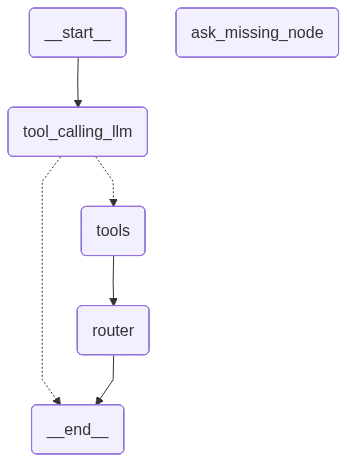

In [28]:
complaint_graph

In [31]:
usr_state = { 
    "user_input": "Laptop is not working."
}

In [32]:
complaint_node(usr_state)

{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'qzc5vhf6s', 'function': {'arguments': '{"user_input":"my laptop is a MacBook Pro and I purchased it on 1 Oct 2025. I am experiencing issues with it."}', 'name': 'extract_info'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 474, 'total_tokens': 513, 'completion_time': 0.108443124, 'prompt_time': 0.04185721, 'queue_time': 0.006261476, 'total_time': 0.150300334}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--3b34c5a6-ed1e-416d-aa3c-19cd703227af-0', tool_calls=[{'name': 'extract_info', 'args': {'user_input': 'my laptop is a MacBook Pro and I purchased it on 1 Oct 2025. I am experiencing issues with it.'}, 'id': 'qzc5vhf6s', 'type': 'tool_call'}], usage_metadata={'input_tokens': 474, 'output_tokens': 39, 'total_tokens': 513}),
  ToolMessage(co

In [151]:
def churn_score_node(state:SupervisorState)->SupervisorState:
    """
        Calculate a churn risk score from user input.
        Returns category: high, medium, or low.
    """
    user_input=state['user_input']
    current_profile = state.get('customer_profile',{})
    system_prompt = """ 
    You are a churn detection assistant.
    Based on the user input, classifiy their churn risk into:
    - high: user explicitly wants to cancel, switch, or sounds very frustrated.
    - medium: user shows dissatisfaction but hasn't decided to cancel yet.
    - low: user just asking questions or mild complaints.

    Examples:
    User: "I'm cancelling this useless service today."
    Churn risk: high

    User: "Your prices keep going up, I don't know if it's worth it anymore."
    Churn risk: medium

    User: "How do I cancel if I ever need to in the future?"
    Churn risk: low

    Respond with only one of: high, medium, low.
    """
    score = llm.invoke([
        {'role':'system', 'content':system_prompt},
        {'role':'user', 'content':user_input}
    ]).content
    
    current_profile['churn_score']=score
    return {"customer_profile":current_profile}

def loyalty_score_node(state:SupervisorState)->SupervisorState:
    """ 
        Provide loyalty score to user based on churn score and customer value. 
    """
    score = state['customer_profile']['churn_score']
    current_profile = state.get('customer_profile')
    reward_weights = {'high': 1.0, "medium": 0.6, "low": 0.2}
    clv_values = {"high": 1000, "medium": 500, "low": 200}
    clv_tier=random.choices(
        ['high','medium','low'],
        weights=[0.25,0.45,0.3],
        k=1
        )[0]

    loyalty_score = reward_weights[score]*clv_values[clv_tier]
    current_profile['loyalty_score']=loyalty_score
    current_profile['clv_tier']=clv_tier

    return {'customer_profile':current_profile}

def reward_node(state:SupervisorState)->SupervisorState:
    """
    Generate a personalized reward offers.
    """

    user_input=state['user_input']
    churn_score=state['customer_profile']['churn_score']
    loyalty_score=state['customer_profile']['loyalty_score']

    system_prompt=""" 
    You are a customer retention assistant. 
    Generate a polite, empathetic message based on the following:
    - The user's message
    - Their churn risk (high, medium, low)
    - Their loyalty score (40-1000)

    Rules:
    - If loyalty score >= 800 → emphasize strong appreciation and give a high reward (e.g., big discount, free premium month).
    - If 500-799 → show gratitude and offer a medium reward (e.g., discount or perk).
    - If 200-499 → acknowledge their value and give a small reward (e.g., loyalty points or small discount).
    - If < 200 → do not give a reward, just apologize and promise to improve.
    - If churn risk = high → always start by apologizing and showing empathy before mentioning any reward.
    - Keep the message short, friendly, concise and natural. Do not include technical terms or scores.
    
    Respond with only the final concise message.
    """

    user_context = f"""
        User message: {user_input}
        Churn risk: {churn_score}
        Loyalty score: {loyalty_score}
        """

    response = llm.invoke([{'role':'system', 'content':system_prompt},
                           {'role':'user','content':user_context}])
    state['messages']=response.content
    return state


In [152]:
graph = StateGraph(SupervisorState)

graph.add_node("supervisor", supervisor_node)
graph.add_node("decision_node", decision_node)
graph.add_node("ask_clarification", ask_clarification_node)
graph.add_node("extract_info", extract_info_node)
graph.add_node("ask_missing_info",ask_missing_info)
graph.add_node("create_ticket",create_ticket_node)
graph.add_node("move_to_execute",move_to_execute)
graph.add_node("respond_greeting",respond_greeting_node)

graph.add_node("Churn",churn_score_node)
graph.add_node("evaluate_user_value",loyalty_score_node)
graph.add_node("offer_retention_action",reward_node)

graph.add_node("inquiry",inquiry_node)

graph.add_edge(START, "supervisor")
graph.add_edge("supervisor", "decision_node")

graph.add_edge("move_to_execute", "decision_node")
graph.add_edge("Churn", "decision_node")
graph.add_edge("evaluate_user_value", "decision_node")

graph.add_edge("ask_clarification", END)
graph.add_edge("ask_missing_info", END)
graph.add_edge("create_ticket", END)
graph.add_edge("offer_retention_action", END)
graph.add_edge("inquiry", END)
graph.add_edge("decision_node", END)


memory=MemorySaver()
service_flow = graph.compile(checkpointer=memory)
config= {"configurable":{"thread_id":"user_complaint_session", "recursion_limit":5}}

NameError: name 'decision_node' is not defined

In [153]:
# service_flow

In [101]:
def agent(usr_input):
    response = service_flow.invoke(
    {"user_input": usr_input},
    config=config
    )

    rprint(response['response'][-1])

In [120]:
usr_input="Today morning"

In [121]:
agent(usr_input)

User Intent is ------>  complaint
--------Mode on:  False
--------Intent on:  complaint
-----Decision:  ask_clarification


I'm glad we're making progress. I'd like to clarify one more detail before we move forward. You mentioned that your
Mac M1 model's screen stopped working suddenly, and this happened today morning. 

To confirm, you're saying that the screen was working fine last night, but when you turned it on today, it wasn't 
working at all? Is that correct?